# Transition energies for InSb and In$_x$Ga$_{1-x}$Sb islands — production results

**Which island sizes emit, and at what energy.** InSb and In$_{0.5}$Ga$_{0.5}$Sb dots in InAs
(Stage 5) and in metamorphic InAs$_{1-y}$Sb$_y$ buffers (Stage 6), at 77 K and 300 K.

## The one equation, and why the electron is not in it

These systems are **broken-gap type II**: the island's valence edge lies *above* the matrix
conduction edge, so the island expels the electron. The transition is spatially indirect,

$$E_\mathrm{trans} = E_c(\mathrm{InAs,\ far}) - E_\mathrm{HH1}$$

and there is **no electron binding subtracted**, because there is no bound electron state to
subtract. That is measured, not assumed. `scripts/electron_binding.py` runs a box series out to
$L = 120$ nm on 2.5, 10 and 20 nm islands; at every size the level decays to $E_c(\mathrm{far})$
as $1/L^2$ **from above**, tracking the empty-box quantum $3G_0\pi^2/(mL^2)$ and never settling
exponentially. Three dimensions have a finite shallow-well threshold and the tensile shell is
nowhere near it — 150 meV deep but only ~1 nm thick gives $V_0R^2 \approx 0.15$ eV·nm² against
the ~3.6 eV·nm² required at $m = 0.026$.

Yeap et al. place their $E_1$ about 17 meV below $E_c(\mathrm{far})$. On this reading that is the
lowest state of their finite FEM domain, the same explanation already reached for their
flat-aspect-ratio hole levels.

## A gap exists only inside a window

Two size limits, running in opposite directions:

| | mechanism |
|---|---|
| **too large** | confinement no longer clears the broken-gap offset; $E_\mathrm{HH1}$ rises past $E_c(\mathrm{far})$ and $E_\mathrm{trans}$ goes negative |
| **too small** | the hole stops being bound at all; the level merges into the matrix valence continuum and what the solver returns is a resonance belonging to the box |

Both are reported as **brackets between adjacent computed points**, never as fitted crossings.
The light-hole tail $\sqrt{G_0/mE}$ diverges as the binding goes to zero, so the box error grows
without bound exactly on approach to the small-size edge — the one place a smooth extrapolation
would look most convincing and be least justified.

## Conventions that are easy to get backwards

- **$\mathrm{AR} = d/h$**, diameter over height, so **larger AR is flatter**. Literature
  convention (Yeap, Rybchenko, Pryor). Records written before 2026-08-05 store `aspect` = $h/d$,
  the reciprocal.
- **Height is derived**: $h = d/\mathrm{AR}$, and it is the *full* vertical extent, not a
  semi-axis. AR 1 is a sphere.
- **Energy zero is the unstrained InAs valence edge.** Yeap's zero is the unstrained *InSb*
  valence edge; the two differ by 590 meV.
- `alloy('InAsSb', y)` takes $y$ as the **antimony** fraction; most of the literature quotes
  arsenic.


In [1]:
import importlib, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

assert os.path.exists('heterostructure.py'), 'run this notebook from the repository root'
sys.path.insert(0, 'scripts')
sys.path.insert(0, '.')

import summarise_transitions as summ
import band_alignment as ba
import hh1_vs_ar as hv

T_COLD, T_HOT = 77.0, 300.0
F_COLD, F_HOT = '_transitions_77K.json', '_transitions_300K.json'
B_COLD, B_HOT = '_transitions_77K_buffer.json', '_transitions_300K_buffer.json'
HC = 1.23984193          # eV.um


def load(path, matrix='InAs'):
    """Plane-wave records only. `last_step` is the discriminator: a file accumulates, and the
    resume key carries base/AR/T but NOT the solver, so pre-plane-wave finite-difference records
    can sit alongside the current ones with no key collision to reveal it."""
    if not os.path.exists(path):
        print(f'MISSING: {path}')
        return []
    rows = [r for r in json.load(open(path)).values()
            if r.get('status') == 'ok' and 'last_step' in r
            and (matrix is None or r['matrix'] == matrix)]
    return sorted(rows, key=lambda r: (r['dot'], r['AR'], r['base']))


cold, hot = load(F_COLD), load(F_HOT)
print(f'Stage 5: {len(cold)} points at {T_COLD:g} K, {len(hot)} at {T_HOT:g} K')
for p in (B_COLD, B_HOT):
    n = len(load(p, matrix=None))
    print(f'Stage 6: {n:3d} points in {p}')

Stage 5: 42 points at 77 K, 42 at 300 K
Stage 6:  84 points in _transitions_77K_buffer.json
Stage 6:  84 points in _transitions_300K_buffer.json


## 1. Stage 5 — InSb and In$_{0.5}$Ga$_{0.5}$Sb in InAs

Every geometry, both temperatures. `verdict` applies the reliability criteria that the sweep
itself cannot; see section 6 for what each one is testing and why two of them were rewritten.

**Negative $E_\mathrm{trans}$ is not a transition energy.** It means the hole level sits above
the matrix conduction edge and no transition exists — the number is how far past closure the
structure is.

In [2]:
def table(cold, hot):
    H = {(r['dot'], r['AR'], r['base']): r for r in hot}
    print(f"{'dot':>16} {'d(nm)':>6} {'AR':>4} {'h(nm)':>6} {'E77(eV)':>9} {'lam77':>7} "
          f"{'E300(eV)':>9} {'dE(meV)':>8} {'bind77':>8} {'verdict':>10}")
    print('-' * 104)
    for r in cold:
        h = H.get((r['dot'], r['AR'], r['base']))
        v, why = summ.grade(r)
        lam = f"{r['lam']:6.2f}u" if r['lam'] else '   ---'
        dE = (r['E_trans'] - h['E_trans']) * 1e3 if h else float('nan')
        print(f"{r['dot']:>16} {r['base']:6.1f} {r['AR']:4g} {r['height']:6.2f} "
              f"{r['E_trans']:+9.4f} {lam:>7} {h['E_trans'] if h else float('nan'):+9.4f} "
              f"{dE:8.1f} {r['binding']:7.1f}m {v:>10}"
              + (f"   ({', '.join(why)})" if why else ''))

table(cold, hot)

             dot  d(nm)   AR  h(nm)   E77(eV)   lam77  E300(eV)  dE(meV)   bind77    verdict
--------------------------------------------------------------------------------------------------------
  In0.50Ga0.50Sb    2.5    1   2.50   +0.2562   4.84u   +0.2024     53.7   151.2m         ok
  In0.50Ga0.50Sb    4.0    1   4.00   +0.1177  10.53u   +0.0641     53.6   289.7m         ok
  In0.50Ga0.50Sb    6.0    1   6.00   +0.0273  45.45u   -0.0262     53.5   380.1m         ok
  In0.50Ga0.50Sb    8.0    1   8.00   -0.0300     ---   -0.0833     53.3   437.4m         ok
  In0.50Ga0.50Sb   10.0    1  10.00   -0.0622     ---   -0.1155     53.3   469.6m         ok
  In0.50Ga0.50Sb   15.0    1  15.00   -0.0998     ---   -0.1531     53.3   507.2m         ok
  In0.50Ga0.50Sb   20.0    1  20.00   -0.1209     ---   -0.1743     53.4   528.2m indicative   (vol -0.10)
  In0.50Ga0.50Sb    2.5    2   1.25   +0.3282   3.78u   +0.2743     53.9    79.2m         ok
  In0.50Ga0.50Sb    4.0    2   2.00   +0.163

### 1a. Transition energy vs shape and size

Left panel answers *what aspect ratio do I need*, right panel *what size*. Filled markers pass
every criterion; open markers are indicative only. Above the zero line the gap is open.

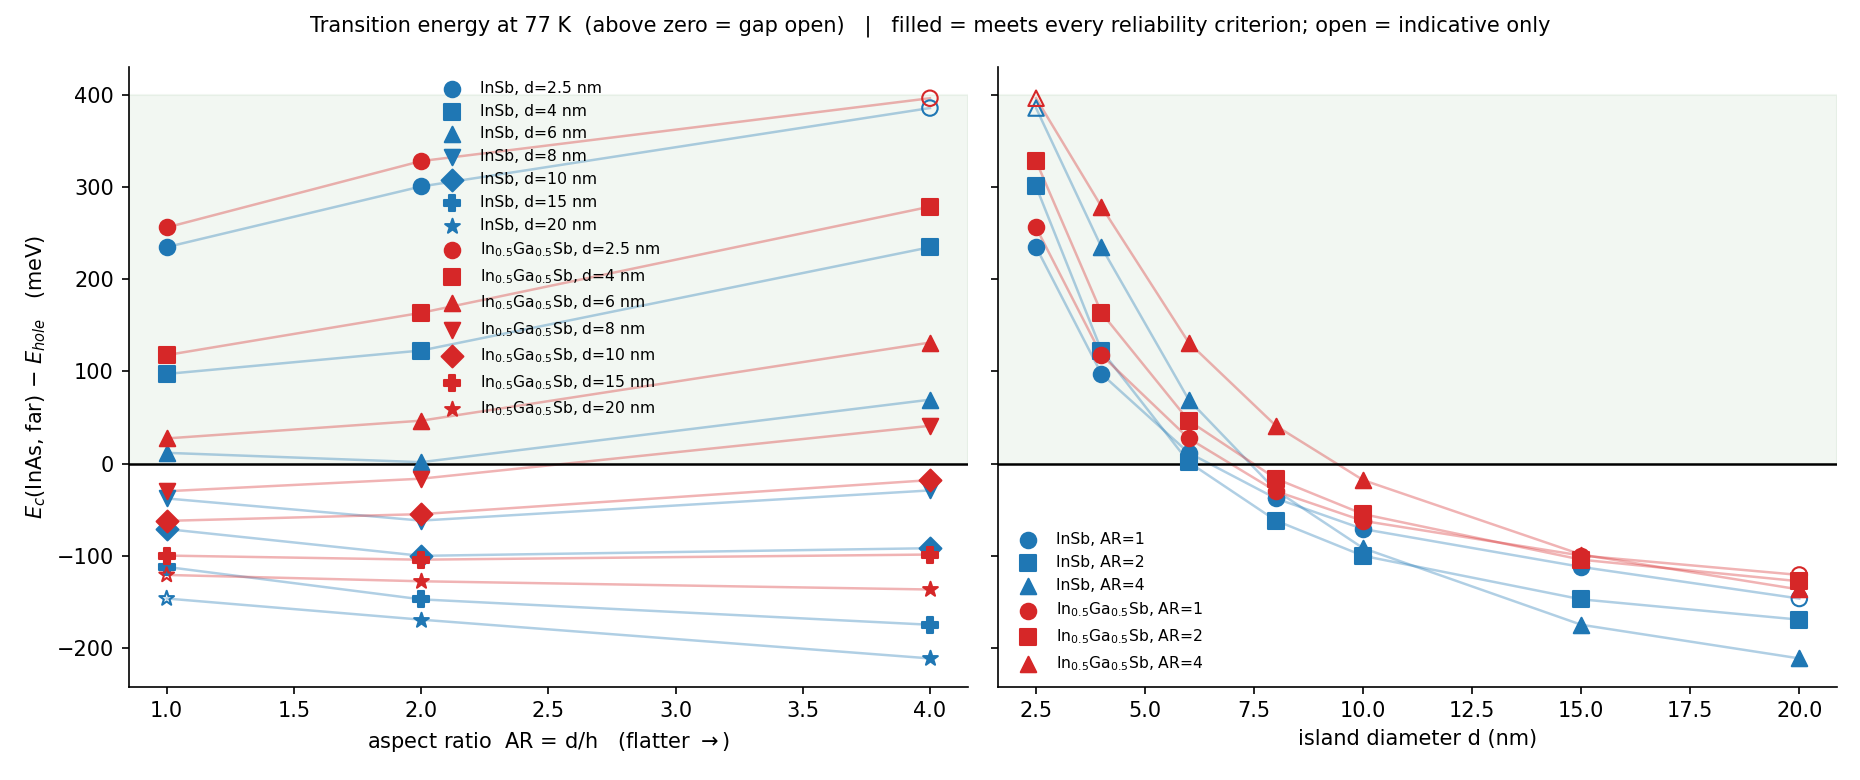

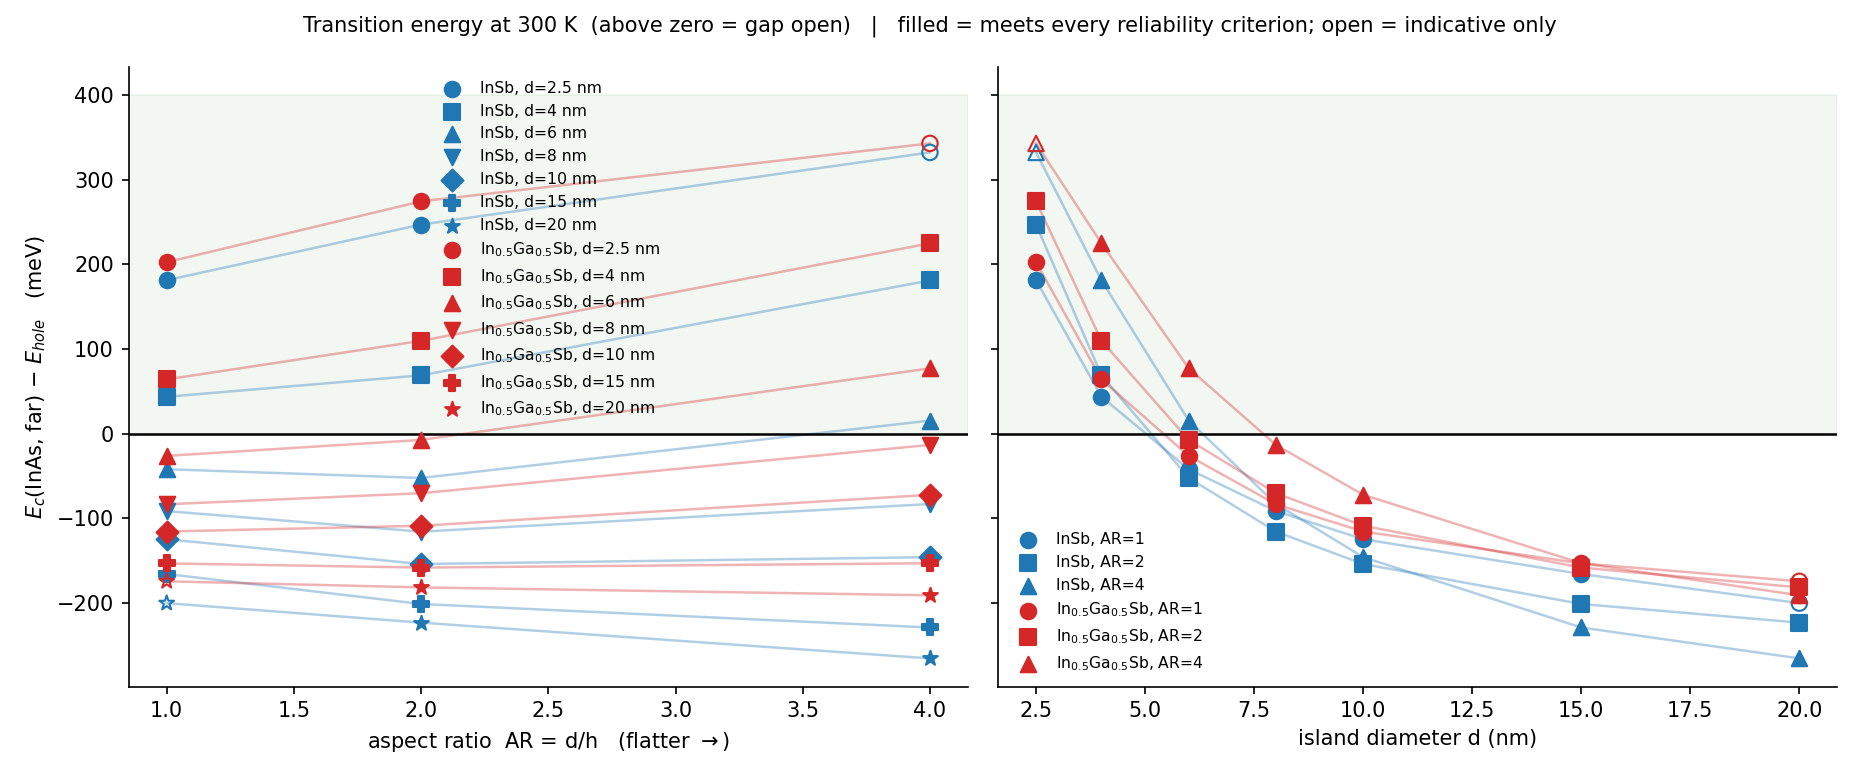

In [3]:
import subprocess
for T in (T_COLD, T_HOT):
    subprocess.run([sys.executable, 'scripts/summarise_transitions.py',
                    f'_transitions_{T:g}K.json', '--plot'],
                   capture_output=True, text=True)

from IPython.display import Image, display
for T in (T_COLD, T_HOT):
    display(Image(filename=f'_transitions_{T:g}K.png'))

## 2. Band alignment, with the computed HH1 levels on it

One panel per (dot, aspect ratio): the strained conduction and **heavy-hole** valence edges
through the island, with every HH1 level at that shape drawn as a horizontal line.

**One profile legitimately carries seven levels.** Continuum elasticity has no length scale, so
at fixed *shape* the strained band edges are size-independent — verified, not assumed, by
sampling the profile at fixed reduced position $x/R$ over a 5× size range and getting identical
values to four decimals. Only the confinement changes with size.

Two things that are easy to get wrong here, both of which produced visibly wrong figures before
being fixed:

1. **The heavy-hole branch is selected by CHARACTER, not by taking $v_1$.** `local_band_edges`
   numbers its branches rather than labelling them, and the ordering inverts in the tensile
   matrix around the island — the heavy hole bends down, the light hole up — so $v_1$ there is
   the light hole and plotting it misreports the barrier by several hundred meV.
2. **Cut through the mask's centre, not the array's.** `island_grid` puts the island base at
   $z=0$ while `ellipsoid_mask` centres the ellipsoid on $z=0$, so the vertical padding is
   asymmetric: on a 10 nm sphere the $z$ axis runs $-9.58 \ldots +19.58$ nm and `nz//2` sits
   5.4 nm *above* the island, in pure matrix. `band_alignment.profile` asserts the two cuts agree
   at the centre, which is the free check that caught it.

wrote _band_alignment_77K.png


    In0.50Ga0.50Sb AR 1: emits at d = 2.5, 4, 6 nm
    In0.50Ga0.50Sb AR 2: emits at d = 2.5, 4, 6 nm
    In0.50Ga0.50Sb AR 4: emits at d = 2.5, 4, 6, 8 nm
              InSb AR 1: emits at d = 2.5, 4, 6 nm
              InSb AR 2: emits at d = 2.5, 4, 6 nm
              InSb AR 4: emits at d = 2.5, 4, 6 nm


wrote _band_alignment_300K.png


    In0.50Ga0.50Sb AR 1: emits at d = 2.5, 4 nm
    In0.50Ga0.50Sb AR 2: emits at d = 2.5, 4 nm
    In0.50Ga0.50Sb AR 4: emits at d = 2.5, 4, 6 nm
              InSb AR 1: emits at d = 2.5, 4 nm
              InSb AR 2: emits at d = 2.5, 4 nm
              InSb AR 4: emits at d = 2.5, 4, 6 nm


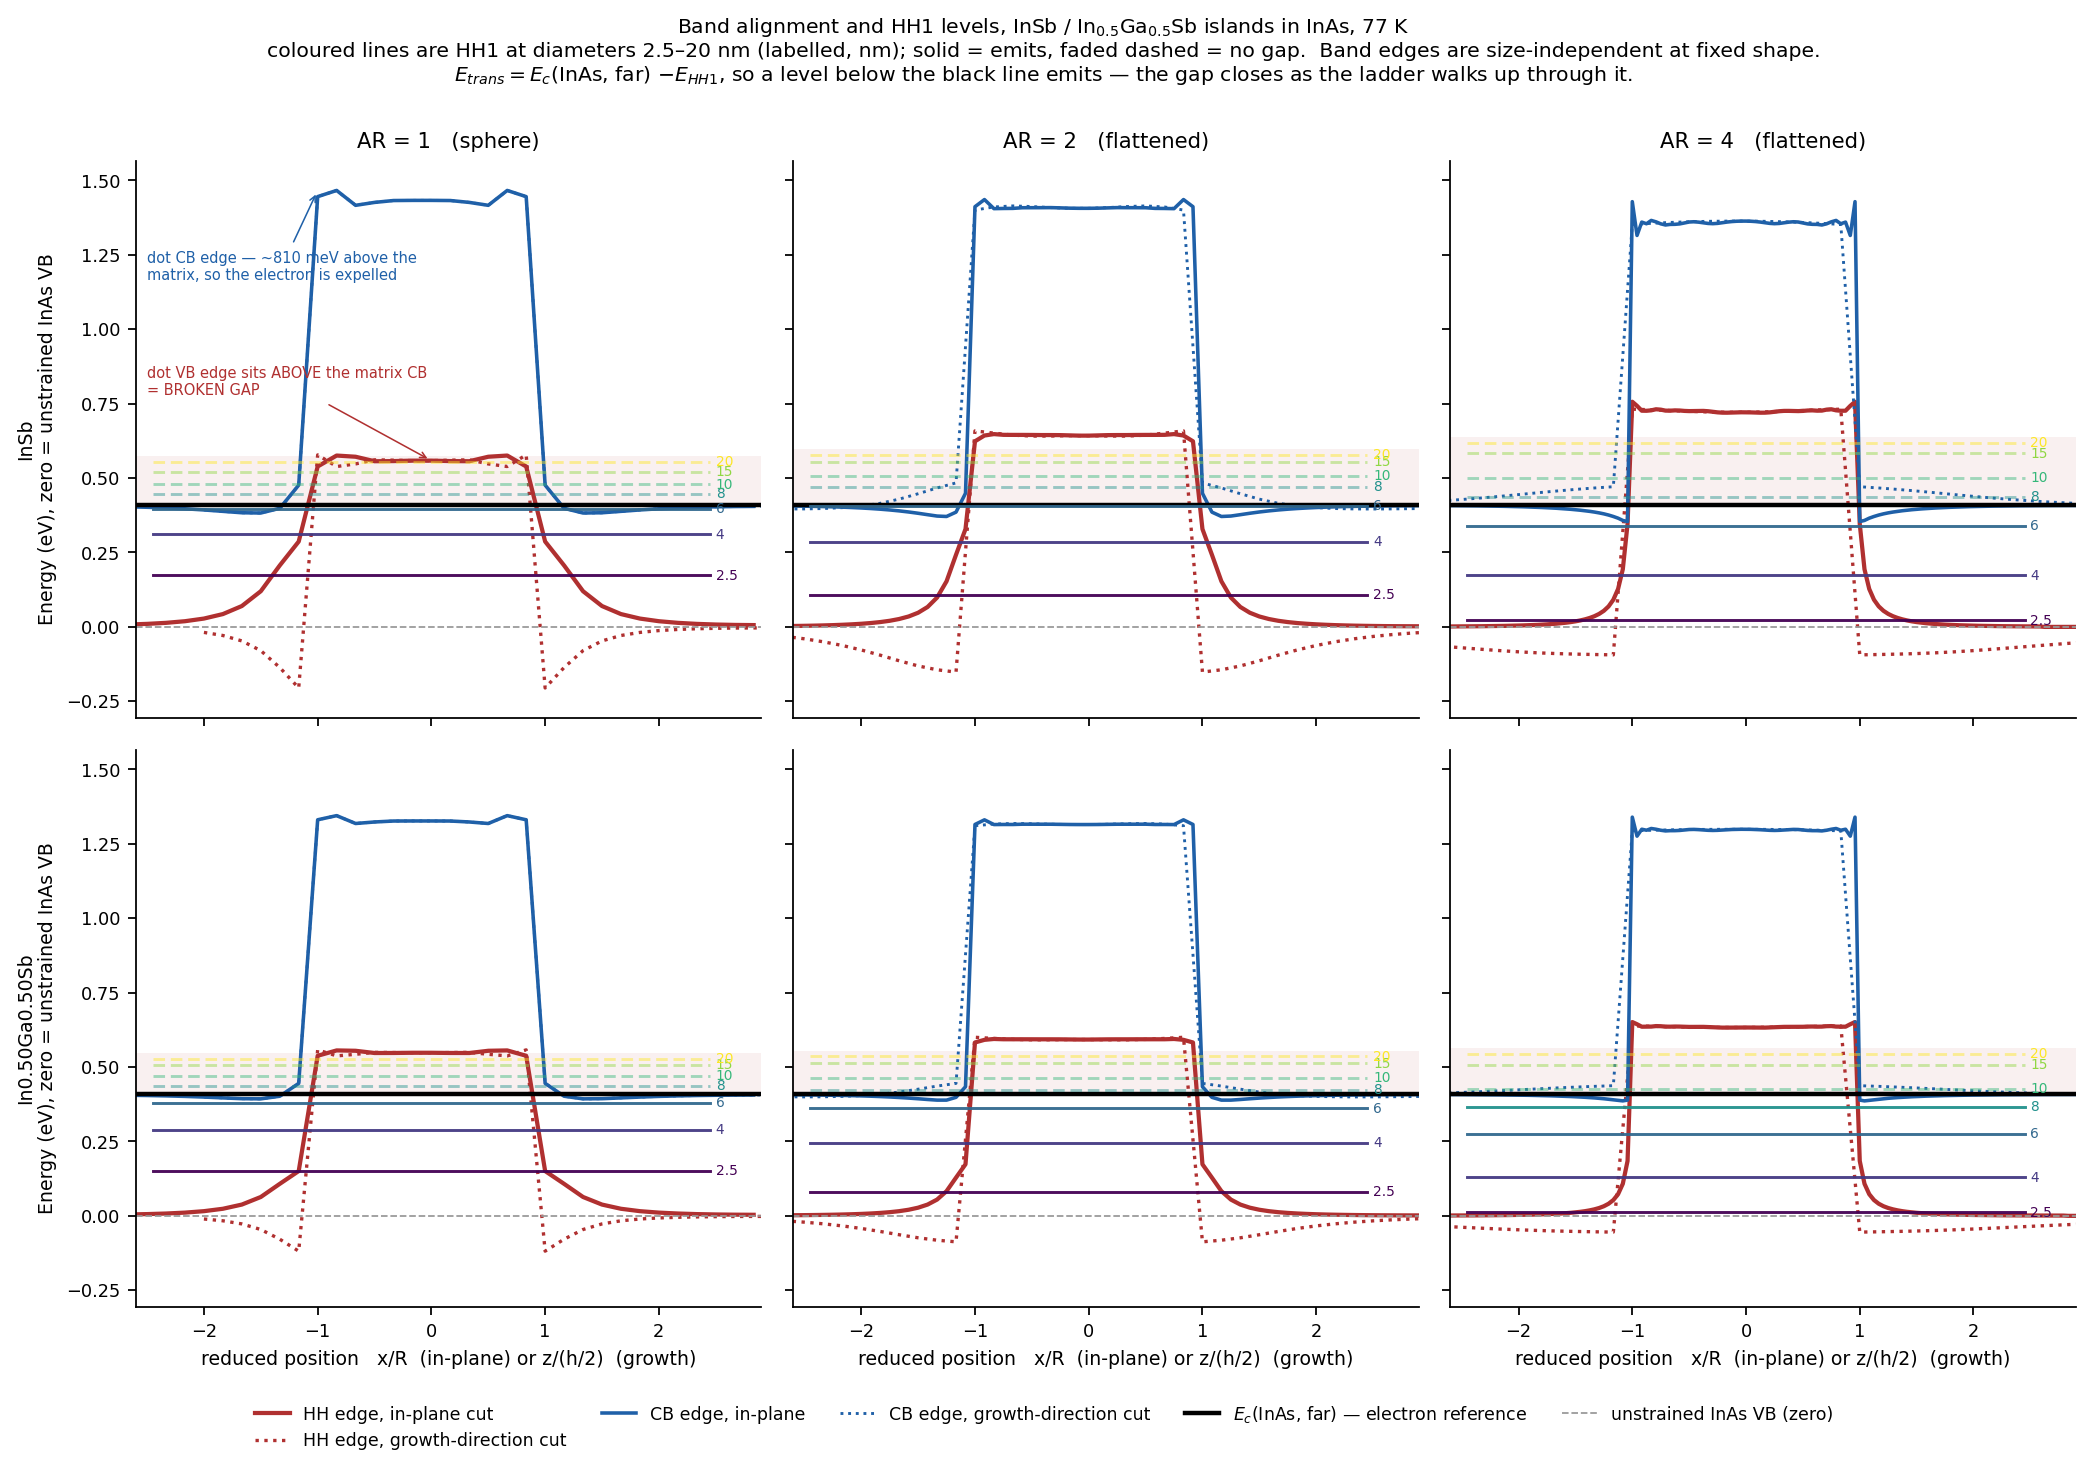

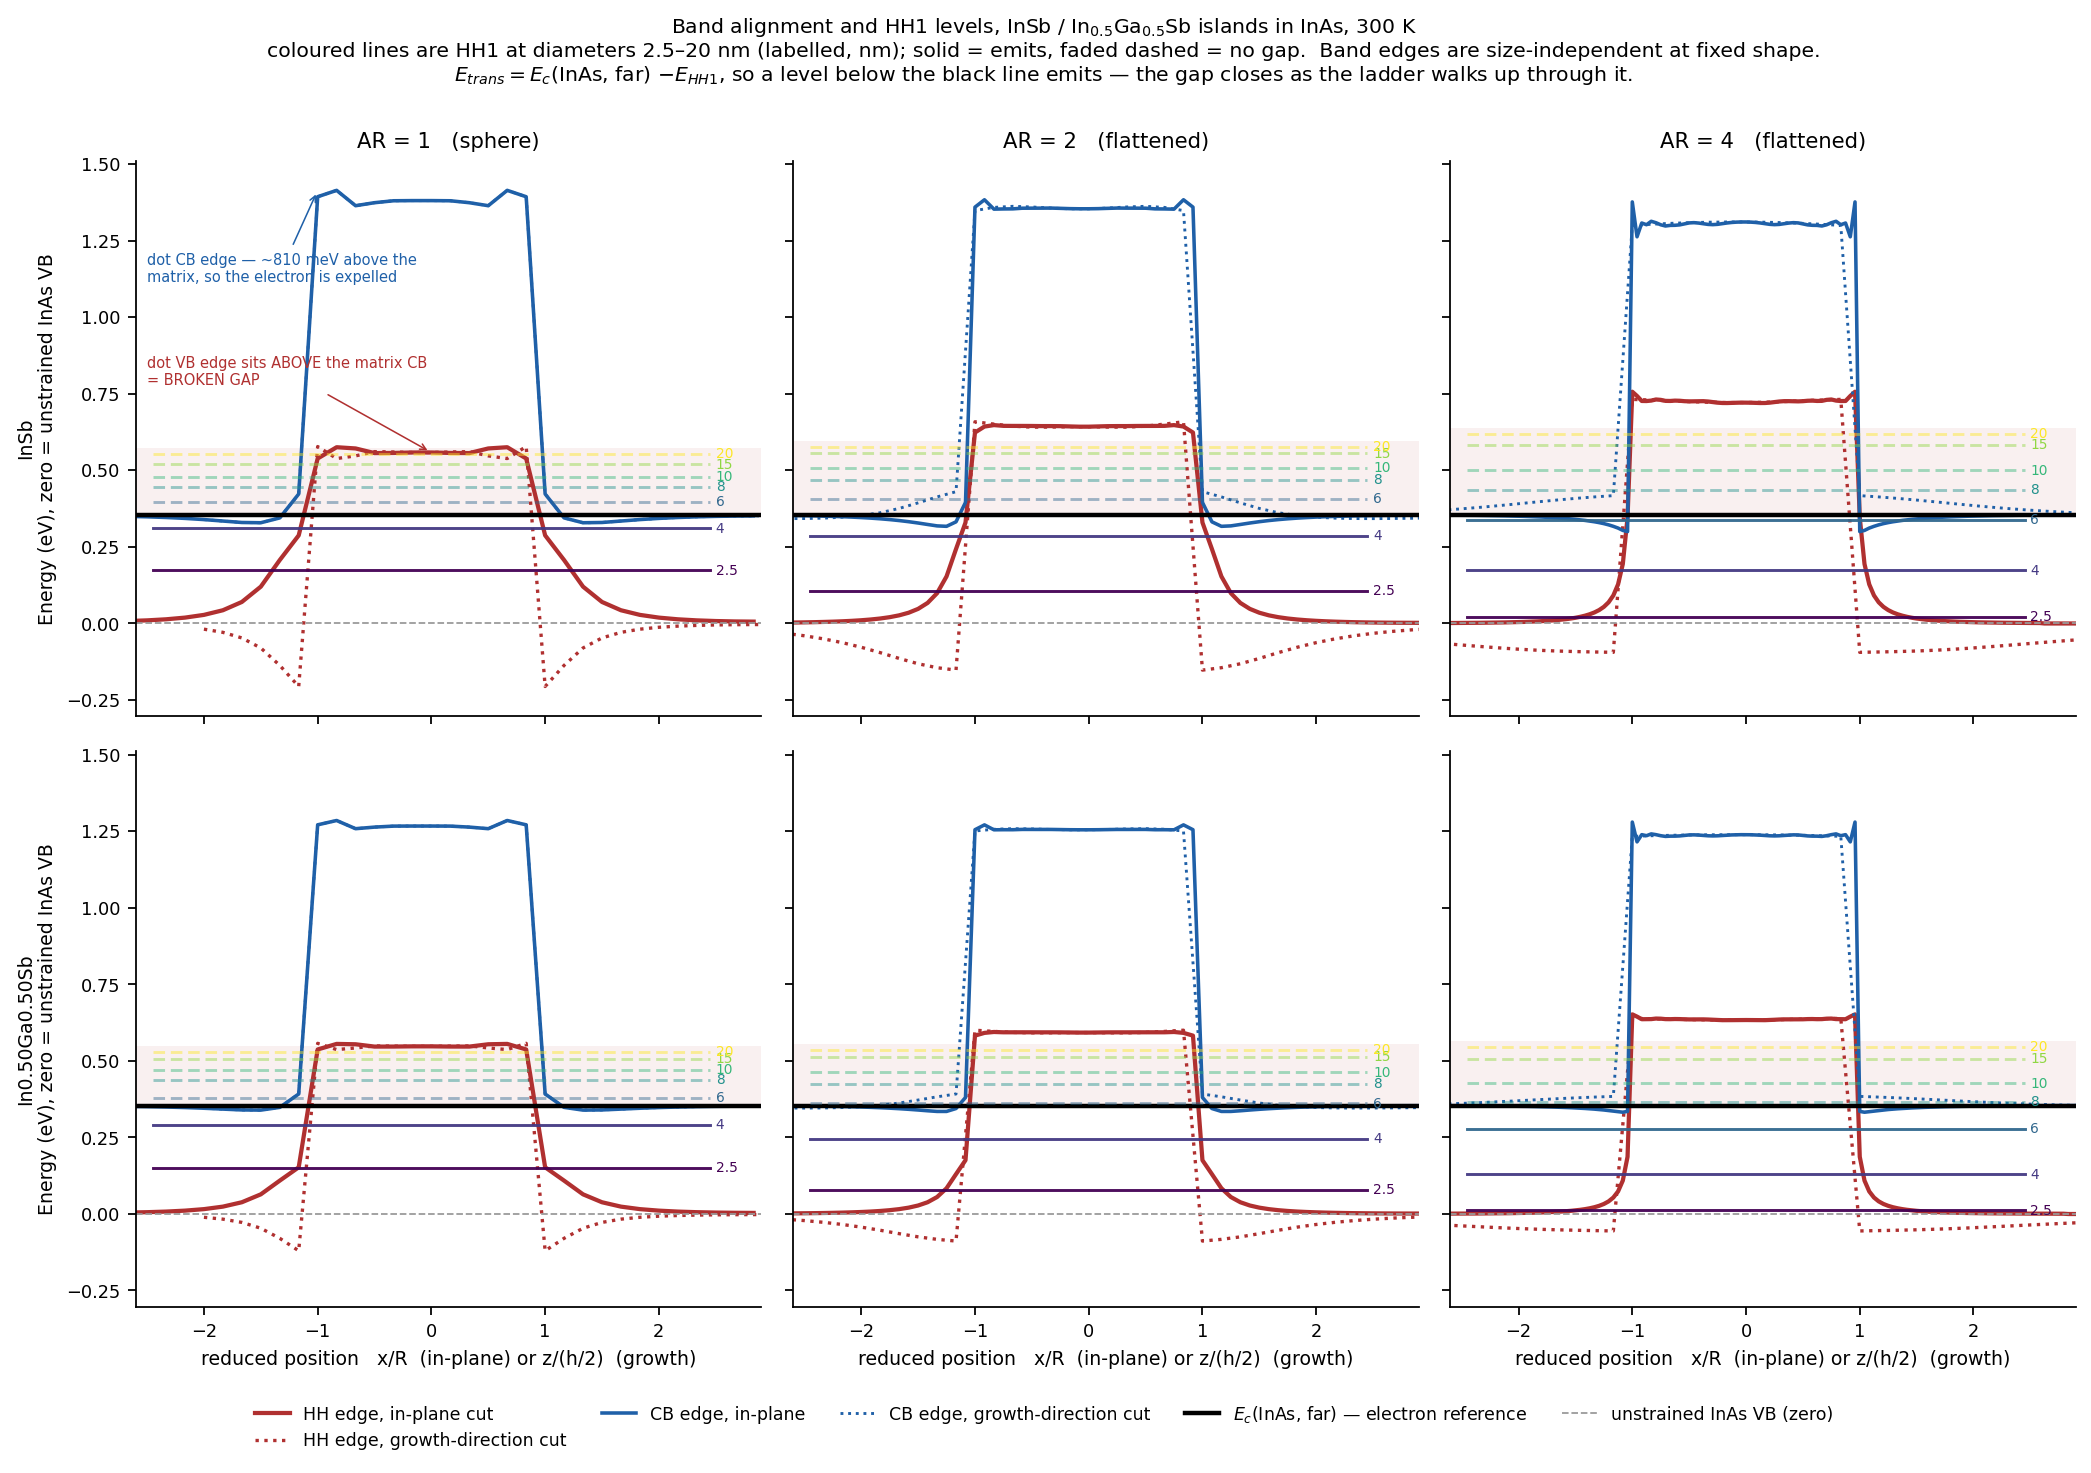

In [4]:
for T in (T_COLD, T_HOT):
    ba.main(T, f'_transitions_{T:g}K.json', f'_band_alignment_{T:g}K.png')
for T in (T_COLD, T_HOT):
    display(Image(filename=f'_band_alignment_{T:g}K.png'))

## 3. HH1 and the electron reference vs aspect ratio

The same information as section 1a, but with the two levels $E_\mathrm{trans}$ is the
*difference* of plotted separately — so the gap closing is a visible **crossing** rather than a
curve passing through zero.

$E_c(\mathrm{InAs,far})$ is flat: it is the matrix conduction edge at infinity, so it depends on
temperature and nothing else — not on dot material, size or shape.

**HH1 moves in opposite directions with AR depending on size**, which the $E_\mathrm{trans}$
plots obscure. Two effects compete: flattening raises the well top (biaxial shear raising the
heavy hole, worth ~130 meV from AR 1 to 4), but flattening at fixed diameter also thins the
island. Below $d \approx 6$ nm the thinning wins and HH1 falls; above it the deeper well wins and
HH1 rises. That is why flattening helps emission at small sizes and hurts at large ones.

wrote _hh1_vs_AR_InSb.png


    77 K: E_c(far) = 0.4074 eV; HH1 below it (gap open) at d = 2.5, 4, 6 nm


    300 K: E_c(far) = 0.3538 eV; HH1 below it (gap open) at d = 2.5, 4, 6 nm


wrote _hh1_vs_AR_InGaSb0.5.png


    77 K: E_c(far) = 0.4074 eV; HH1 below it (gap open) at d = 2.5, 4, 6, 8 nm


    300 K: E_c(far) = 0.3538 eV; HH1 below it (gap open) at d = 2.5, 4, 6 nm


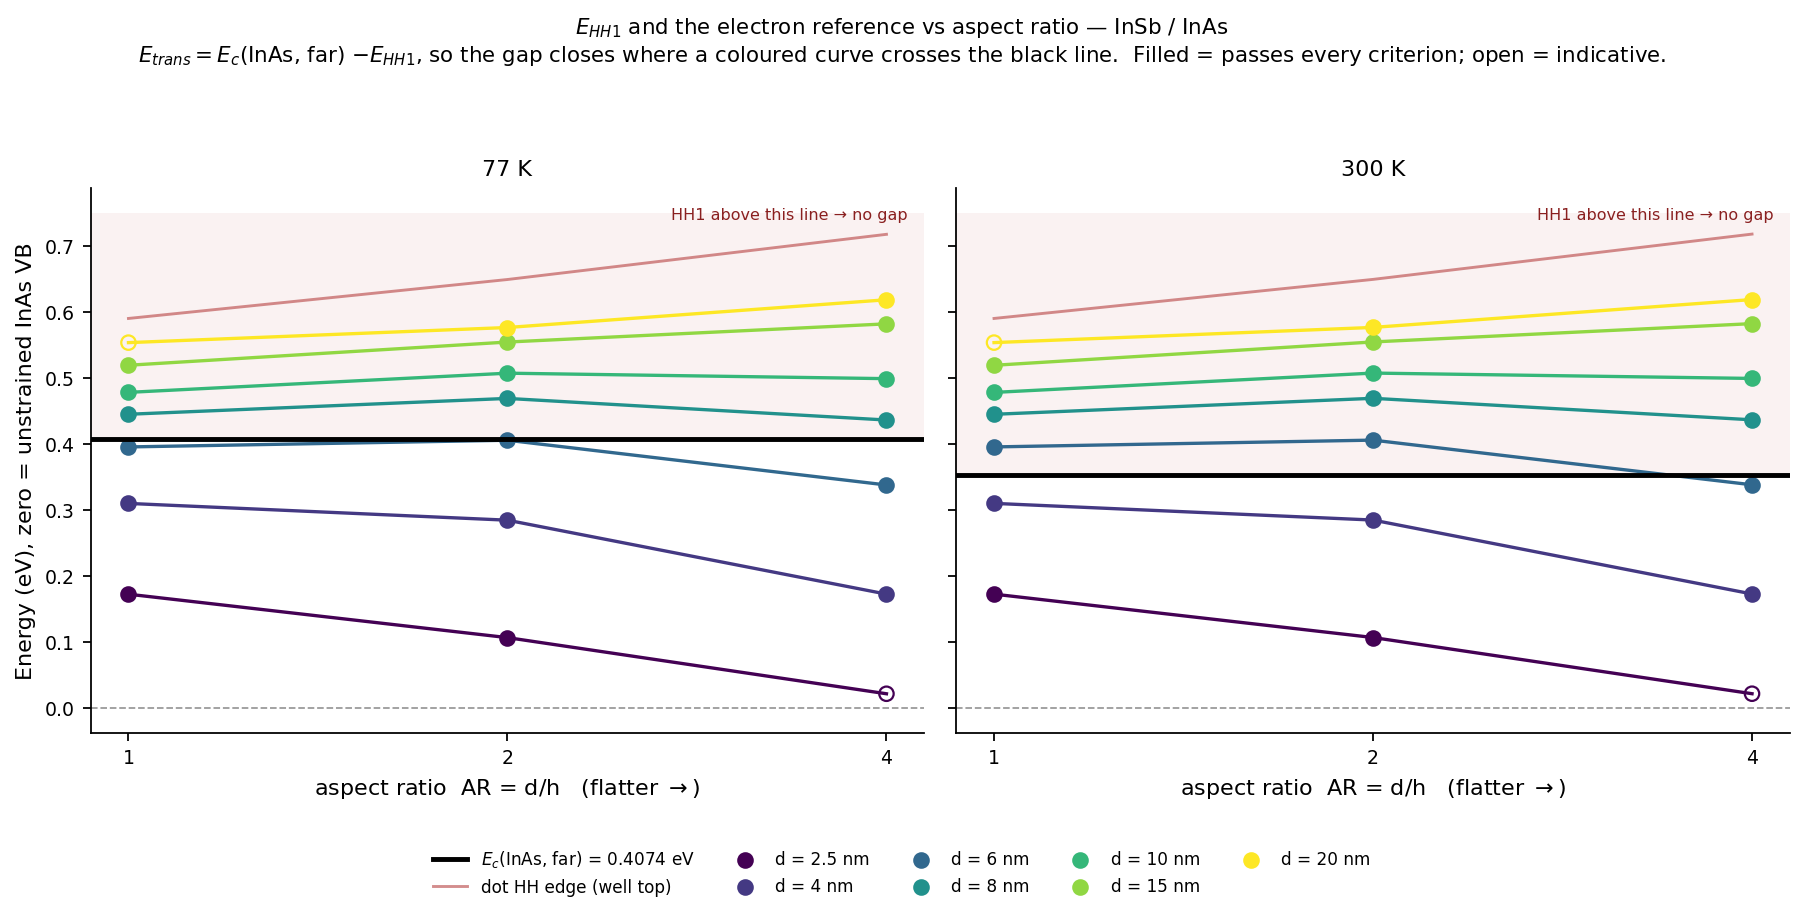

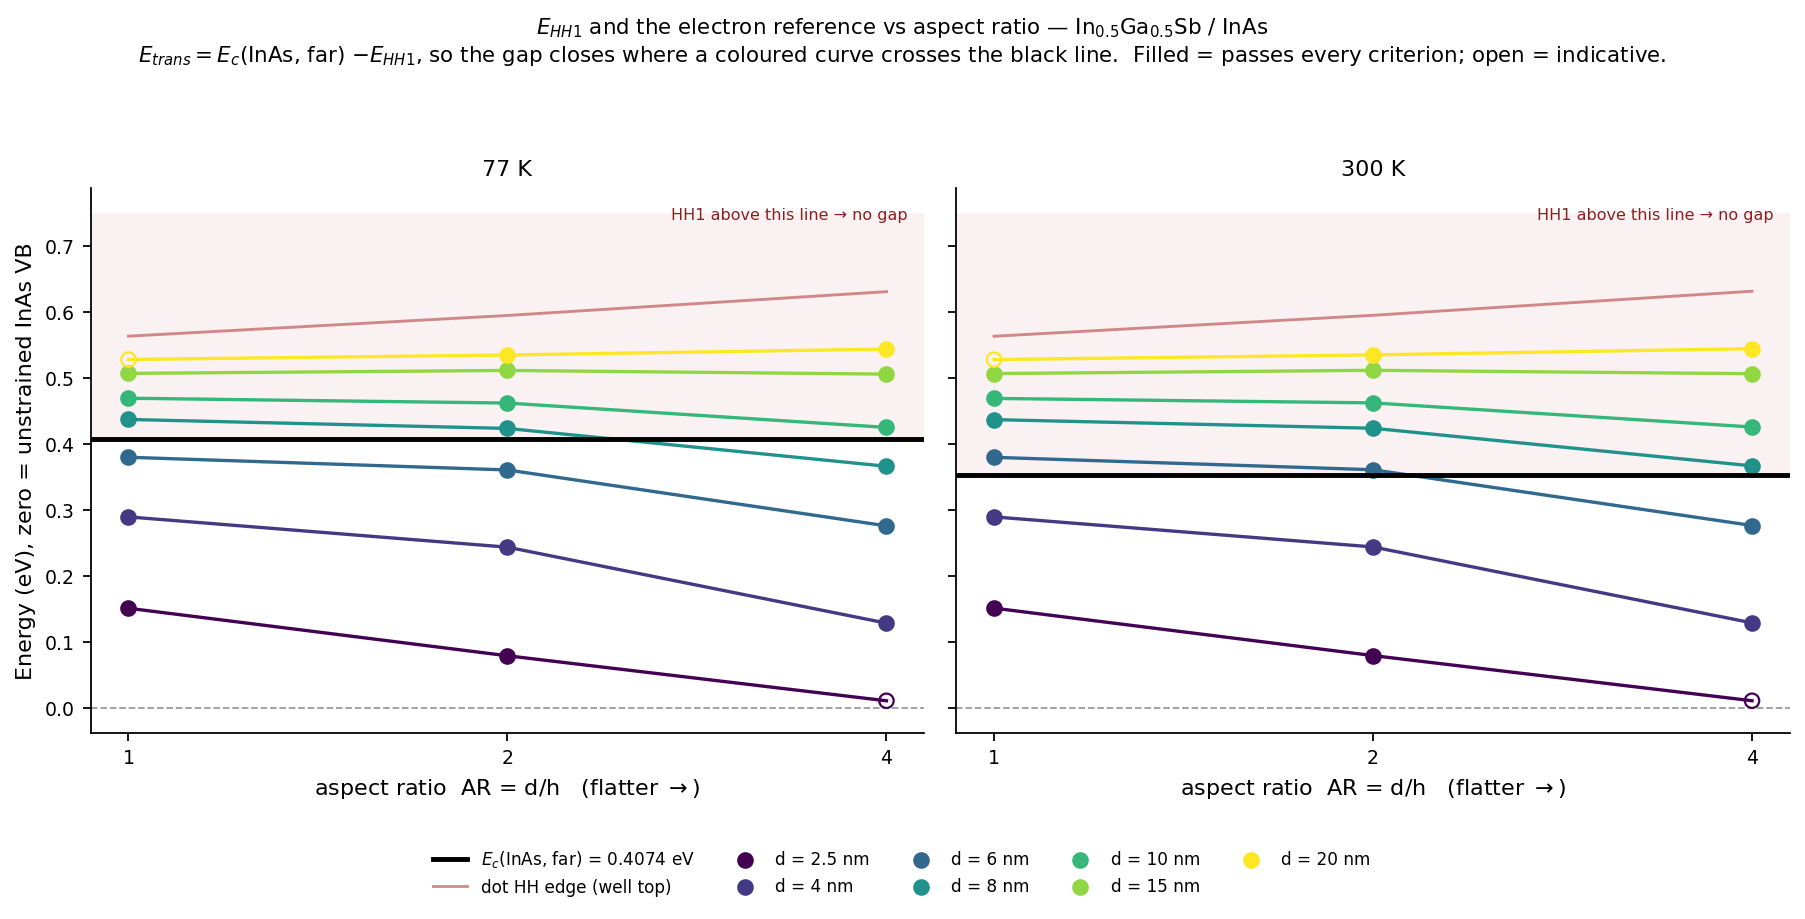

In [5]:
hv.main('_hh1_vs_AR_{label}.png')
for label in ('InSb', 'InGaSb0.5'):
    display(Image(filename=f'_hh1_vs_AR_{label}.png'))

## 4. The emission window

Brackets between adjacent computed points, graded rows only. This is the deliverable: **which
sizes emit and which are too big.**

In [6]:
for T, rows in ((T_COLD, cold), (T_HOT, hot)):
    print(f'=== {T:g} K')
    summ.emission_window(rows)
    print()

=== 77 K

EMISSION WINDOW (brackets between adjacent points, graded rows only)
     In0.50Ga0.50Sb AR  1.00: gap closes between d = 6 and 8 nm   [1 excluded]
     In0.50Ga0.50Sb AR  2.00: gap closes between d = 6 and 8 nm
     In0.50Ga0.50Sb AR  4.00: gap closes between d = 8 and 10 nm   [1 excluded]
               InSb AR  1.00: gap closes between d = 6 and 8 nm   [1 excluded]
               InSb AR  2.00: gap closes between d = 6 and 8 nm
               InSb AR  4.00: gap closes between d = 6 and 8 nm   [1 excluded]

=== 300 K

EMISSION WINDOW (brackets between adjacent points, graded rows only)
     In0.50Ga0.50Sb AR  1.00: gap closes between d = 4 and 6 nm   [1 excluded]
     In0.50Ga0.50Sb AR  2.00: gap closes between d = 4 and 6 nm
     In0.50Ga0.50Sb AR  4.00: gap closes between d = 6 and 8 nm   [1 excluded]
               InSb AR  1.00: gap closes between d = 4 and 6 nm   [1 excluded]
               InSb AR  2.00: gap closes between d = 4 and 6 nm
               InSb AR  4.00: 

## 5. Temperature: the 77 → 300 K redshift

The sharpest available test that survives an imperfect hole solver, being a *difference*. Yeap
compute ≈45 meV and measure ≈40; the target was 45 ± 10 meV, flat across AR.

Nearly all of it lands on $E_c(\mathrm{InAs})$: the gap shrinks with temperature while the
valence-band offset is temperature-independent, and the hole binding barely moves.

In [7]:
H = {(r['dot'], r['AR'], r['base']): r for r in hot}
d = np.array([(r['E_trans'] - H[k]['E_trans']) * 1e3
              for r in cold if (k := (r['dot'], r['AR'], r['base'])) in H])
db = np.array([abs(r['binding'] - H[k]['binding'])
               for r in cold if (k := (r['dot'], r['AR'], r['base'])) in H])
print(f'redshift over {len(d)} geometries: mean {d.mean():.1f} meV, '
      f'range {d.min():.1f}-{d.max():.1f}, std {d.std():.2f}')
print(f'hole binding moves by at most {db.max():.2f} meV over the same range')
print(f"-> {'PASS' if abs(d.mean() - 45) <= 10 and d.std() < 10 else 'OUTSIDE TARGET'}"
      f'  (target 45 +- 10 meV, flat to +-10)')

redshift over 42 geometries: mean 53.8 meV, range 53.3-54.2, std 0.23
hole binding moves by at most 0.63 meV over the same range
-> PASS  (target 45 +- 10 meV, flat to +-10)


## 6. Stage 6 — does an InAs$_{1-y}$Sb$_y$ buffer help?

The buffer reduces misfit (InSb: −6.48% → −4.53% at $y = 0.3$), which should relieve strain and
so reduce the broken-gap overlap. The expectation was near-cancellation. **The measurement says
cancellation, but net-negative at every geometry.**

The decomposition is the point, because only one of the two terms is geometry-dependent:

$$\Delta E_\mathrm{trans} = \underbrace{\Delta E_c(\mathrm{far})}_{\text{a constant}} -
\underbrace{\Delta E_\mathrm{HH1}}_{\text{depends on the island}}$$

Adding Sb to InAs shrinks the matrix gap (strong bowing), dropping $E_c(\mathrm{far})$ by a fixed
amount at every geometry. Less misfit also means less confinement, returning *part* of that as
lost hole binding — but how much comes back depends on the island. So the cancellation is
partial and geometry-dependent, and never favourable.

In [8]:
base = {(r['dot'], r['AR'], r['base']): r for r in cold}
buf = load(B_COLD, matrix=None)
if not buf:
    print('no buffer data yet -- run: python scripts/transition_energies.py --buffer')
else:
    for m in sorted({r['matrix'] for r in buf}):
        sel = [r for r in buf if r['matrix'] == m]
        common = [(base[k], r) for r in sel if (k := (r['dot'], r['AR'], r['base'])) in base]
        if not common:
            continue
        dE = np.array([(b['E_trans'] - a['E_trans']) * 1e3 for a, b in common])
        dB = np.array([b['binding'] - a['binding'] for a, b in common])
        dEc = (common[0][1]['Ec_far'] - common[0][0]['Ec_far']) * 1e3
        assert len({round(b['Ec_far'], 9) for _, b in common}) == 1
        print(f'{m}: {len(common)} common geometries')
        print(f'   Ec_far shift  {dEc:+8.1f} meV   (identical at every geometry)')
        print(f'   binding shift {dB.mean():+8.1f} meV   (range {dB.min():+.1f} to {dB.max():+.1f})')
        print(f'   E_trans shift {dE.mean():+8.1f} meV   (range {dE.min():+.1f} to {dE.max():+.1f})')
        print(f'   -> helps at {int((dE > 0).sum())} of {len(dE)} geometries\n')

InAs0.70Sb0.30: 42 common geometries
   Ec_far shift    -194.7 meV   (identical at every geometry)
   binding shift   -147.6 meV   (range -204.6 to -8.5)
   E_trans shift    -47.2 meV   (range -186.2 to +9.8)
   -> helps at 4 of 42 geometries

InAs0.85Sb0.15: 42 common geometries
   Ec_far shift    -112.4 meV   (identical at every geometry)
   binding shift    -74.7 meV   (range -102.3 to -6.1)
   E_trans shift    -37.7 meV   (range -106.4 to -10.2)
   -> helps at 0 of 42 geometries



In [9]:
# Where the gap closes, plain InAs vs each buffer.
for path, label in ((F_COLD, 'InAs'), (B_COLD, 'InAsSb buffers')):
    rows = load(path, matrix=None)
    if not rows:
        continue
    print(f'=== {label} ({os.path.basename(path)})')
    for m in sorted({r['matrix'] for r in rows}):
        print(f'  -- matrix {m}')
        summ.emission_window([r for r in rows if r['matrix'] == m])
    print()

=== InAs (_transitions_77K.json)
  -- matrix InAs

EMISSION WINDOW (brackets between adjacent points, graded rows only)
     In0.50Ga0.50Sb AR  1.00: gap closes between d = 6 and 8 nm   [1 excluded]
     In0.50Ga0.50Sb AR  2.00: gap closes between d = 6 and 8 nm
     In0.50Ga0.50Sb AR  4.00: gap closes between d = 8 and 10 nm   [1 excluded]
               InSb AR  1.00: gap closes between d = 6 and 8 nm   [1 excluded]
               InSb AR  2.00: gap closes between d = 6 and 8 nm
               InSb AR  4.00: gap closes between d = 6 and 8 nm   [1 excluded]

=== InAsSb buffers (_transitions_77K_buffer.json)
  -- matrix InAs0.70Sb0.30

EMISSION WINDOW (brackets between adjacent points, graded rows only)
     In0.50Ga0.50Sb AR  1.00: gap closes between d = 4 and 6 nm   [2 excluded]
     In0.50Ga0.50Sb AR  2.00: gap closes between d = 6 and 8 nm   [1 excluded]
     In0.50Ga0.50Sb AR  4.00: gap closes between d = 8 and 10 nm   [2 excluded]
               InSb AR  1.00: gap closes between 

## 7. Excited hole states — these are not two-level systems

The production sweep solves $k=4$, which on a **sphere** returns the fourfold $\Gamma_8$-like
$F=3/2$ ground multiplet rather than an excited state (measured splitting at AR 1: 0.0–0.1 meV).
Shape anisotropy splits it, so at AR 2 and 4 the second level is genuinely distinct.

A $k=12$ probe on two emitting geometries found **four to seven bound hole doublets**, every one
exactly Kramers-paired and none above the spectrum bound. Because an excited hole is *less*
bound, its transition energy is *larger* — a ladder of shorter-wavelength lines from the same
island.

**The box limit bites from the top of the ladder down**, since the light-hole tail is
$\sqrt{G_0/mE}$ and the binding falls as you go up. The verdicts below apply that per level
against the 4 nm crop actually used.

**What is missing is intensity, and it is not a detail.** The transition is spatially indirect
and the electron is an unbound matrix continuum state, so oscillator strengths are not a
bound–bound overlap. Yeap report the strength dropping more than an order of magnitude from 2.5
to 10 nm. These are line *positions*, not a predicted spectrum.

In [10]:
LADDERS = {   # k = 12, 77 K, crop 4 nm; from scripts/transition_energies.hole_ladder
    'InSb d=6 nm AR=4': [0.3381, 0.2331, 0.2240, 0.1847, 0.1361, 0.1215, 0.1011],
    'InSb d=4 nm AR=2': [0.2847, 0.1880, 0.1583, 0.1459, 0.0649, 0.0417],
}
EC, CROP = 0.4074, 4.0
for name, lv in LADDERS.items():
    print(f'{name}   (77 K, crop {CROP:g} nm)')
    print(f"  {'lvl':>4} {'E_HH':>8} {'bind':>8} {'E_trans':>8} {'lam(um)':>8} {'tail':>7}  verdict")
    for i, e in enumerate(lv):
        et, tail = EC - e, np.sqrt(summ.G0 / (summ.M_LH * e))
        ok = tail <= summ.TAIL_OVER_PAD * CROP
        print(f'  HH{i+1:<2} {e:+8.4f} {e*1e3:7.1f}m {et:+8.4f} {HC/et:8.2f} {tail:6.2f}n  '
              f"{'converged' if ok else 'BOX-LIMITED'}")
    print()

InSb d=6 nm AR=4   (77 K, crop 4 nm)
   lvl     E_HH     bind  E_trans  lam(um)    tail  verdict
  HH1   +0.3381   338.1m  +0.0693    17.89   2.74n  converged
  HH2   +0.2331   233.1m  +0.1743     7.11   3.30n  converged
  HH3   +0.2240   224.0m  +0.1834     6.76   3.37n  converged
  HH4   +0.1847   184.7m  +0.2227     5.57   3.71n  converged
  HH5   +0.1361   136.1m  +0.2713     4.57   4.32n  converged
  HH6   +0.1215   121.5m  +0.2859     4.34   4.57n  converged
  HH7   +0.1011   101.1m  +0.3063     4.05   5.01n  converged

InSb d=4 nm AR=2   (77 K, crop 4 nm)
   lvl     E_HH     bind  E_trans  lam(um)    tail  verdict
  HH1   +0.2847   284.7m  +0.1227    10.10   2.99n  converged
  HH2   +0.1880   188.0m  +0.2194     5.65   3.68n  converged
  HH3   +0.1583   158.3m  +0.2491     4.98   4.01n  converged
  HH4   +0.1459   145.9m  +0.2615     4.74   4.17n  converged
  HH5   +0.0649    64.9m  +0.3425     3.62   6.26n  BOX-LIMITED
  HH6   +0.0417    41.7m  +0.3657     3.39   7.80n  BOX-LIM

## 8. What the reliability criteria are, and why two of them were replaced

`summarise_transitions.grade` applies six tests. Two of them were wrong for this sweep in
opposite directions, and both failures are worth keeping written down.

**`artifact_ratio` is gone, and should be.** It was $(0.046/h^2)/V_0$ — the size of the
*symmetrized* six-band operator's interface runaway against the well depth, a contamination
estimate for a solver whose spectrum was unbounded at an abrupt interface. Burt–Foreman ordering
removed the cause, so there is nothing to take a ratio of. Grading now uses `last_step`, the last
rung of the monotone-from-below cutoff ladder, which *bounds* the remainder rather than
estimating it, plus `n_above_bound`, which must be zero.

**A flat `loc >= 0.75` would have discarded the entire interesting half of the sweep.** That is a
large-dot criterion. A 2.5 nm island genuinely holds its hole at 55% because a small well spills;
a 10 nm one reaches 88%. Both are correct. Applying 0.75 marks the small-island end — where the
gap actually opens — as unreliable, while passing the large islands that have no gap at all.

The replacement went through two forms, and the first was also wrong. A ratio against the
**random-vector baseline** (island volume / box volume) fixes the small end but breaks the large
one: at $d = 20$ nm the island is 26.7% of the box, so "5× baseline" demands 133% and no state
can satisfy it — it flagged two 98%-localised points. What survives is the **enhancement**,

$$\mathrm{enh} = \frac{\mathrm{loc} - \mathrm{baseline}}{1 - \mathrm{baseline}}$$

which is 0 for a state that ignores the island and 1 for one entirely inside it.

In [11]:
print(f'cells across height   >= {summ.CELLS_MIN:g}')
print(f'cutoff last_step      <= {summ.STEP_MAX:g} meV')
print(f'loc enhancement       >= {summ.LOC_ENHANCEMENT:g}')
print(f'lh tail               <= {summ.TAIL_OVER_PAD:g} x crop pad')
print('n_above_bound          = 0;   binding > 0 (not a resonance);   |vol_err| <= 0.10')
print()
for T, rows in ((T_COLD, cold), (T_HOT, hot)):
    bad = [(r, summ.grade(r)[1]) for r in rows if summ.grade(r)[0] != 'ok']
    print(f'{T:g} K: {len(rows) - len(bad)} of {len(rows)} pass')
    for r, why in bad:
        print(f"   {r['dot']:>16} d={r['base']:g} AR={r['AR']:g}: {', '.join(why)}")

cells across height   >= 6
cutoff last_step      <= 5 meV
loc enhancement       >= 0.4
lh tail               <= 1.5 x crop pad
n_above_bound          = 0;   binding > 0 (not a resonance);   |vol_err| <= 0.10

77 K: 38 of 42 pass
     In0.50Ga0.50Sb d=20 AR=1: vol -0.10
     In0.50Ga0.50Sb d=2.5 AR=4: 4.2 cells, lh tail 15.2 nm > 4 nm crop, loc 9% vs baseline 0.2% (enh 0.08)
               InSb d=20 AR=1: vol -0.10
               InSb d=2.5 AR=4: 4.2 cells, lh tail 10.8 nm > 4 nm crop, loc 16% vs baseline 0.2% (enh 0.16)
300 K: 38 of 42 pass
     In0.50Ga0.50Sb d=20 AR=1: vol -0.10
     In0.50Ga0.50Sb d=2.5 AR=4: 4.2 cells, lh tail 15.2 nm > 4 nm crop, loc 9% vs baseline 0.2% (enh 0.09)
               InSb d=20 AR=1: vol -0.10
               InSb d=2.5 AR=4: 4.2 cells, lh tail 10.8 nm > 4 nm crop, loc 16% vs baseline 0.2% (enh 0.16)


## Provenance

| what | where |
|---|---|
| production sweep | `scripts/transition_energies.py` (`--300K`, `--buffer`, `--redo-unconverged`) |
| grading and window | `scripts/summarise_transitions.py` |
| box/cutoff calibration | `scripts/sweep_calibration.py` |
| electron binding | `scripts/electron_binding.py` |
| band alignment figure | `scripts/band_alignment.py` |
| HH1 vs AR figure | `scripts/hh1_vs_ar.py` |
| Yeap validation | `scripts/yeap_fig6_ar.py`, `scripts/plot_yeap_fig6.py` |
| solver | `kp_planewave.py` (Burt–Foreman ordering) |

Numerical settings behind every point: strain pad 8/6 nm, k·p crop 4 nm, cutoff ladder to
$g_\max = \pi/2h$ (the grid Nyquist, a ceiling rather than a choice), $h$ clamped to
$[0.15, 0.50]$ nm. The crop is worth about −2 meV on a 2.5 nm island and under −0.5 meV on a
10 nm one, always *understating* $E_\mathrm{trans}$; the $h$ ceiling exists because tying $h$ to
the island size shrinks the plane-wave basis as the island grows, which left the entire AR 1
column unconverged in the first production run.